# Extract sensitivity from histogram distribution

## steps:

- 1. modify the old function

- 2. sanity check with E_nr

- 3. extract curve from E_ee with lindhard model

- 4. implementing other yield models, extract more sensitivities

- 5. plot and make comparison


In [2]:
from analysis.sensitivity import get_Nexp_from_CL
from analysis.rate_models import get_rate_ben
from analysis.dm_params import DMParams
from analysis.sensitivity import scan_sensitivity_hist
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from analysis.yield_functions import yield1, lindhard, damicm_fit, damicm_no_fano, damicm_fano


## sanity check with E_nr & extract curve from E_ee from yield models

In [3]:
params = DMParams() # all in default values
npoints = 30
mass_test, xs_test = scan_sensitivity_hist(params, npoints=npoints)
np.savez("sensitivities_NR/yield1.npz", mass=np.array(mass_test), xs=np.array(xs_test)* 1e-36) #use cm2 unit for cross section

mass_lindhard, xs_lindhard = scan_sensitivity_hist(params, yield_function = lindhard,npoints=npoints)
np.savez("sensitivities_NR/lindhard.npz", mass=np.array(mass_lindhard), xs=np.array(xs_lindhard)* 1e-36)

mass_damicm_fit, xs_damicm_fit = scan_sensitivity_hist(params, yield_function = damicm_fit, npoints=npoints)
np.savez("sensitivities_NR/damicm_fit.npz", mass=np.array(mass_damicm_fit), xs=np.array(xs_damicm_fit)* 1e-36)

mass_damicm_no_fano, xs_damicm_no_fano = scan_sensitivity_hist(params, yield_function = damicm_no_fano, npoints=npoints)
np.savez("sensitivities_NR/damicm_no_fano.npz", mass=np.array(mass_damicm_no_fano), xs=np.array(xs_damicm_no_fano)* 1e-36)

mass_damicm_fano, xs_damicm_fano = scan_sensitivity_hist(params, yield_function = damicm_fano, npoints=npoints)
np.savez("sensitivities_NR/damicm_fano.npz", mass=np.array(mass_damicm_fano), xs=np.array(xs_damicm_fano)* 1e-36)

Scanning m_D: 100%|██████████| 30/30 [00:06<00:00,  4.66mass/s]


In [4]:
# hist result no yield:
data_test = np.load("sensitivities_NR/yield1.npz") 
mass_test, xs_test = data_test["mass"],data_test["xs"]

# lindhard yield:
data_lindhard = np.load("sensitivities_NR/lindhard.npz") 
mass_lindhard, xs_lindhard = data_lindhard["mass"],data_lindhard["xs"]

# damicm_fit 
data_damicm_fit = np.load("sensitivities_NR/damicm_fit.npz") 
mass_damicm_fit, xs_damicm_fit = data_damicm_fit["mass"],data_damicm_fit["xs"]

data_damicm_no_fano = np.load("sensitivities_NR/damicm_no_fano.npz") 
mass_damicm_no_fano, xs_damicm_no_fano = data_damicm_no_fano["mass"],data_damicm_no_fano["xs"]

data_damicm_fano = np.load("sensitivities_NR/damicm_fano.npz") 
mass_damicm_fano, xs_damicm_fano = data_damicm_fano["mass"],data_damicm_fano["xs"]


<Figure size 1008x1440 with 0 Axes>

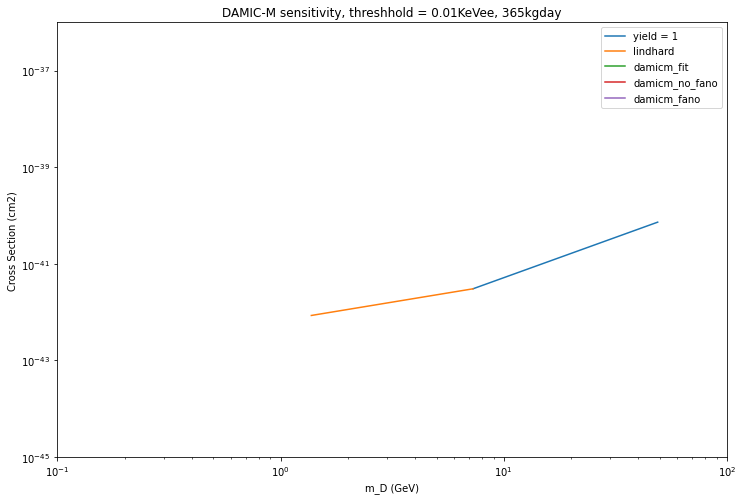

In [5]:
plt.figure(figsize=(14, 20))
fig, ax1 = plt.subplots(figsize=(12, 8))
# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default color cycle
ax1.plot(mass_test, xs_test, label='yield = 1')
# rad_file = '/Users/iumicuszhu/Downloads/Default Dataset.csv'
# data_rad = np.loadtxt(rad_file, delimiter=",") 
# mass_rad, xs_rad = data_rad[:,0], data_rad[:,1]*1e36
# ax1.plot(data_rad, xs_rad, label='from radomir, yield = 1')

ax1.plot(mass_lindhard, xs_lindhard, label='lindhard')
ax1.plot(mass_damicm_fit, xs_damicm_fit, label='damicm_fit')
ax1.plot(mass_damicm_no_fano, xs_damicm_no_fano, label='damicm_no_fano')
ax1.plot(mass_damicm_fano, xs_damicm_fano, label='damicm_fano')



ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('DAMIC-M sensitivity, threshhold = 0.01KeVee, 365kgday')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('Cross Section (cm2)')
ax1.set_xlim(0.1,100)
ax1.set_ylim(1e-45,1e-36)

ax1.legend(title='new params')
ax1.legend(fontsize = 10)

plt.show()

fig.savefig("plots/my_funcs", dpi=600) 